# Multivariate Analysis

Multivariate analysis involves the simultaneous exploration of **three or more variables**.

In real-world data science, problems are rarely isolated to pairs of features:
- A relationship between two variables often depends critically on a third (interaction effect).
- Omitting key variables can distort our conclusions (Simpson's Paradox / Confounding).

In this notebook, we implement and interpret:
1. **Multi-channel visual encodings:** `hue`, `style`, and `size` in scatter plots
2. **Multivariate pair plots:** Separating target classes across multiple feature planes
3. **Faceted grids (`sns.catplot` & `FacetGrid`):** Breaking complex interactions into structured subplots
4. **Pivoted heatmaps:** Quantifying multi-variable survival probabilities (Sex + Class + Age)

---


## 1. Setup & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

df = pd.read_csv('../../data/titanic.csv')
print(f"Dataset shape: {df.shape}")
df.head(3)


Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 2. Multi-Channel Visual Encodings on a Scatter Plot

We can map up to 5 variables on a single 2D plane using visual channels:
- **X-axis:** `Age` (continuous numerical)
- **Y-axis:** `Fare` (continuous numerical)
- **Color (`hue`):** `Survived` (binary categorical target)
- **Marker Shape (`style`):** `Sex` (binary categorical)
- **Marker Size (`size`):** `Pclass` (ordinal categorical, scaled appropriately)


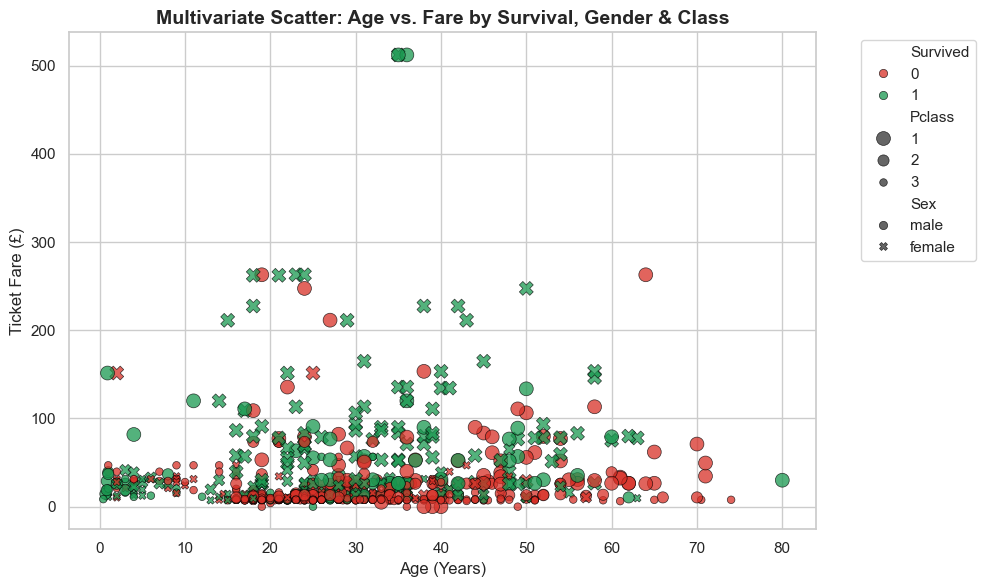

In [2]:
plt.figure(figsize=(10, 6))

# Map 5 variables simultaneously
scatter = sns.scatterplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Survived',
    style='Sex',
    size='Pclass',
    sizes=(100, 30), # Larger points for 1st class, smaller for 3rd
    palette={0: '#d73027', 1: '#1a9850'},
    alpha=0.75,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Multivariate Scatter: Age vs. Fare by Survival, Gender & Class', fontsize=14, weight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Ticket Fare (£)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save plot
plt.savefig('../../outputs/plots/multivariate_scatter_5_vars.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation
By combining these 5 channels in one plot, several multi-variable patterns surface at once:
1. **Upper-left luxury cluster:** High fares (> £100) are almost exclusively 1st class (large markers), and the vast majority are green (survived), predominantly female.
2. **Lower dense band:** Low fares (< £30) are mostly 3rd class (small markers), heavily dominated by red circles (perished males).
3. **Young passengers (< 10 years):** Noticeable cluster of green markers at the far left, showing preferential survival of children across fare ranges.


## 3. Multivariate Pair Plot

A pair plot conditioned on our target variable (`hue='Survived'`) projects multiple pairwise feature projections side-by-side, highlighting which feature combinations provide the cleanest decision boundaries.


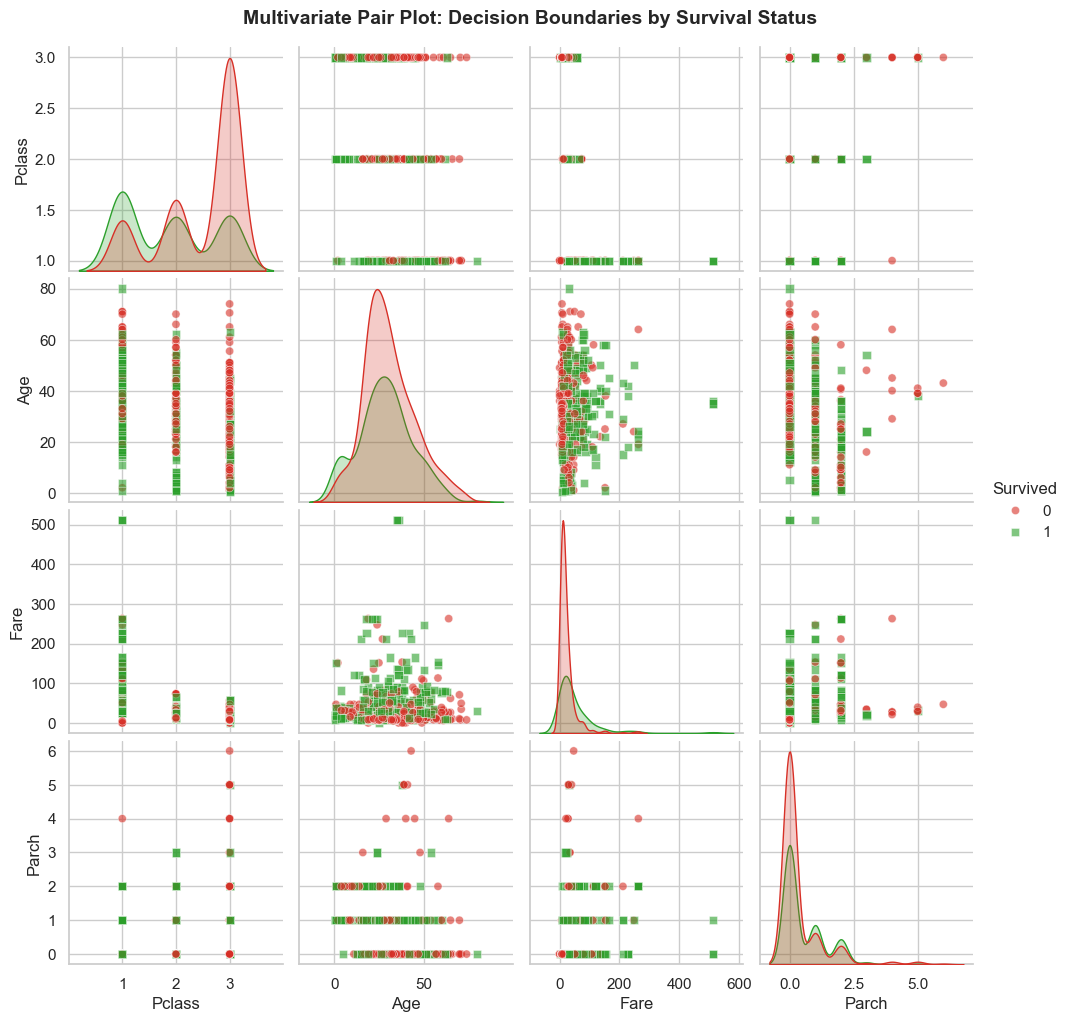

In [3]:
# Select numerical features for the multivariate pair plot
feature_subset = ['Survived', 'Pclass', 'Age', 'Fare', 'Parch']

pairplot = sns.pairplot(
    df[feature_subset].dropna(),
    hue='Survived',
    palette={0: '#d73027', 1: '#2ca02c'},
    markers=['o', 's'],
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 35}
)

pairplot.fig.suptitle('Multivariate Pair Plot: Decision Boundaries by Survival Status', y=1.02, fontsize=14, weight='bold')
plt.show()


### Observation
- The `Fare` vs `Pclass` combination creates the strongest linear separation between survivors (green squares) and non-survivors (red circles).
- The `Parch` vs `Age` combination highlights that high-parch passengers with very low age (young children traveling with parents) have strong survival clusters.


## 4. Faceted Categorical Analysis (`sns.catplot`)

When encodings on a single plot become cluttered, **faceting** splits the data into subplots across categorical levels.

Let us test the historical hypothesis: **Did the "Women and Children First" rule hold equally across all passenger classes?**


/var/folders/z8/bjhnq05d3ygdk3mnkcvm6ys80000gn/T/ipykernel_7099/2034539386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


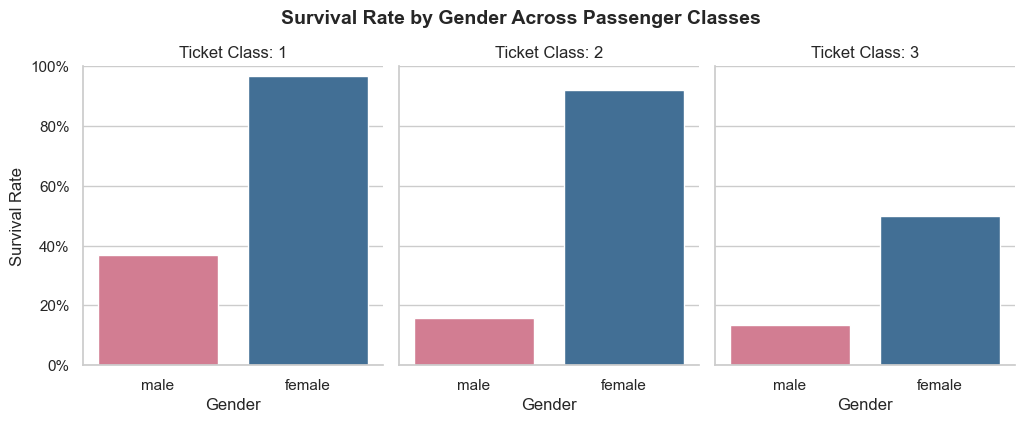

In [4]:
# Faceted bar plot: Survival rate across Gender faceted by Class
g = sns.catplot(
    data=df,
    x='Sex',
    y='Survived',
    col='Pclass',
    kind='bar',
    palette=['#e06f8b', '#3470a3'],
    errorbar=None,
    height=4,
    aspect=0.85
)

g.set_axis_labels("Gender", "Survival Rate")
g.set_titles("Ticket Class: {col_name}")
g.set(ylim=(0, 1))

# Format Y-axis as percentage
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

plt.suptitle('Survival Rate by Gender Across Passenger Classes', y=1.05, fontsize=14, weight='bold')
plt.show()


### Observation
Look at the stark interaction between Gender and Class:
- **1st Class Females:** Nearly **97%** survived.
- **2nd Class Females:** **92%** survived.
- **3rd Class Females:** Only **50%** survived! Half of 3rd class women perished.
- **Males:** 1st class males had a **37%** survival rate—nearly triple that of 3rd class males (**13.5%**).
Class dramatically modified the effect of gender on survival.


### 4.1 Faceted Distribution Grid (`FacetGrid`)

Now let us look at the full age distribution for each combination of Class and Gender, separated by whether they survived.


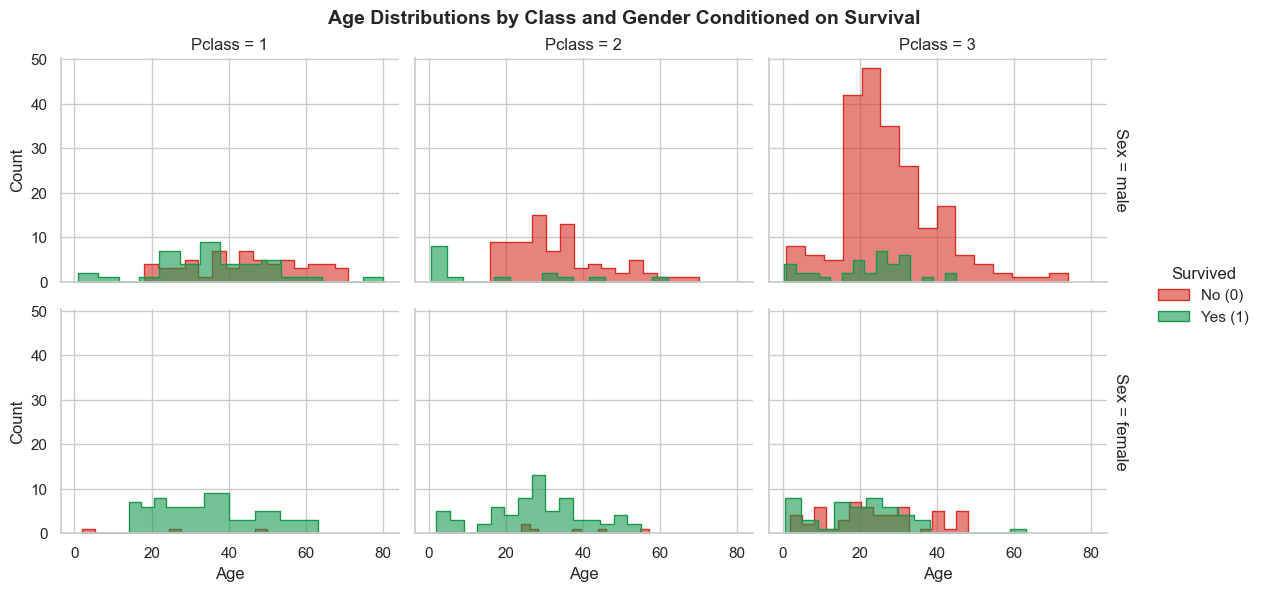

In [5]:
g = sns.FacetGrid(
    df, 
    col='Pclass', 
    row='Sex', 
    hue='Survived', 
    palette={0: '#d73027', 1: '#1a9850'}, 
    height=3, 
    aspect=1.3,
    margin_titles=True
)

g.map(sns.histplot, 'Age', bins=15, alpha=0.6, element='step')
g.add_legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Age Distributions by Class and Gender Conditioned on Survival', fontsize=14, weight='bold')
plt.show()


### Observation
- In **Class 1 and Class 2** (both male and female), children under age 10 are almost 100% green (survived).
- In **Class 3**, there are significant numbers of children under age 10 who are red (perished).
This reveals that even child survival was contingent upon socioeconomic class.


## 5. Multi-Variable Aggregation with Pivot Tables & Heatmaps

A 3-variable pivot table calculates the exact survival rate conditioned on multiple dimensions.


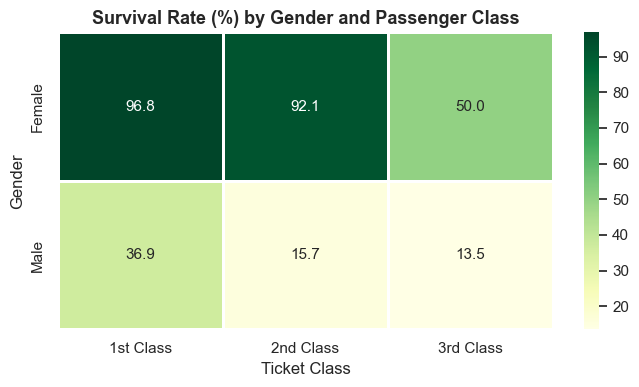

In [6]:
# Survival Rate (%) conditioned on Sex and Pclass
pivot_gender_class = df.pivot_table(
    index='Sex', 
    columns='Pclass', 
    values='Survived', 
    aggfunc='mean'
) * 100

plt.figure(figsize=(7, 4))
sns.heatmap(
    pivot_gender_class, 
    annot=True, 
    fmt='.1f', 
    cmap='YlGn', 
    cbar=True,
    linewidths=1,
    yticklabels=['Female', 'Male'],
    xticklabels=['1st Class', '2nd Class', '3rd Class']
)

plt.title('Survival Rate (%) by Gender and Passenger Class', fontsize=13, weight='bold')
plt.ylabel('Gender')
plt.xlabel('Ticket Class')
plt.tight_layout()

# Save plot
plt.savefig('../../outputs/plots/multivariate_pivot_heatmap.png', dpi=150)
plt.show()


### Observation
The heatmap quantifies the interaction cleanly:
- 1st Class Female: **96.8%**
- 2nd Class Female: **92.1%**
- 3rd Class Female: **50.0%**
- 1st Class Male: **36.9%**
- 2nd Class Male: **15.7%**
- 3rd Class Male: **13.5%**


## 6. Real Pattern Discovery: Child Survival by Travel Class

Let us create an explicit boolean feature `IsChild` (passengers aged under 16) and analyze how survival varies when combining **`IsChild` + `Pclass`**.


In [7]:
# Create child indicator feature
df_analysis = df.copy()
df_analysis['IsChild'] = df_analysis['Age'].apply(lambda age: 'Child (<16)' if age < 16 else ('Adult (>=16)' if pd.notnull(age) else 'Unknown'))

# Compute survival table
child_class_pivot = df_analysis[df_analysis['IsChild'] != 'Unknown'].pivot_table(
    index='IsChild',
    columns='Pclass',
    values='Survived',
    aggfunc=['mean', 'count']
)

# Format as percentages
child_survival_rates = (child_class_pivot['mean'] * 100).round(1)
child_counts = child_class_pivot['count']

print("--- Survival Rates (%) by Age Group and Class ---")
print(child_survival_rates)
print("\n--- Passenger Counts by Age Group and Class ---")
print(child_counts)


--- Survival Rates (%) by Age Group and Class ---
Pclass           1      2     3
IsChild                        
Adult (>=16)  65.0   41.6  20.2
Child (<16)   83.3  100.0  43.1

--- Passenger Counts by Age Group and Class ---
Pclass          1    2    3
IsChild                    
Adult (>=16)  180  154  297
Child (<16)     6   19   58


### Observation & Practical Revelation
- **1st Class Children:** **83.3%** survived (5 out of 6).
- **2nd Class Children:** **100.0%** survived (19 out of 19)! Every single child in 2nd class was saved.
- **3rd Class Children:** Only **43.1%** survived (22 out of 51). Over half of 3rd class children drowned.

**Why this matters for Machine Learning:**
If an ML algorithm is only given `Age` or only given `Pclass`, it misses the compound effect:
- Being a child in 2nd class is a near-guarantee of survival ($100\%$).
- Being a child in 3rd class still resulted in a $< 50\%$ survival chance.
Multivariate analysis allows us to discover these interaction features before model training!


### Key Takeaways
1. Multivariate analysis is essential to detect confounding variables and non-linear feature interactions.
2. Use visual channels (`hue`, `style`, `size`) thoughtfully without overloading a single chart.
3. Use `sns.catplot` and `FacetGrid` to partition multi-variable comparisons into digestible small multiples.
4. Multivariable pivot tables and heatmaps provide crystal-clear verification of interaction effects (e.g., Sex + Class + Child survival rates).
